# 走性と loom 回避の走行シミュレーション

PC 上の机上検討である。カメラもモーターも使わない。左右の赤と青のカウントを与えて、独立 2 輪のヨーがどちらを向くかを見る。

赤と青は別の部分グラフのまま使う。

- 赤は `data/malecns/steer-dna02/` の DNa02、左右 1 本。電流は外部から入れる。
- 青は `data/malecns/gf-loom/` のうち LC4、LPLC2、DNp01。TTMn、PSI、DLMn は跳躍と飛翔なので、ヨーには使わない。

見たいのは次の 4 つ。

- 右の赤で右、左の赤で左へ曲がる
- 右の青で左、左の青で右へ避ける
- 青が閾値を超えたフレームは DNa02 の発火を捨て、DNp01 の左右差だけを使う
- その切替で、赤い目標へ向かいながら青い障害をよけられるか

これは計測にフィットしたモデルではない。結合がどの細胞のあいだにあり、化学シナプスが何個か、だけが connectome から来ている。発火率への変換、閾値、車速は下の定数で選んでいる。膜の式と定数は `notebooks/gf_loom_sim.ipynb` と揃えてある。


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.feather as feather
from matplotlib import font_manager

ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "malecns" / "gf-loom" / "neurons.feather").exists():
    ROOT = ROOT.parent
LOOM = ROOT / "data" / "malecns" / "gf-loom"
STEER = ROOT / "data" / "malecns" / "steer-dna02"

for candidate in (
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJKjp-Regular.otf",
):
    if Path(candidate).exists():
        font_manager.fontManager.addfont(candidate)
        plt.rcParams["font.family"] = font_manager.FontProperties(fname=candidate).get_name()
        break
else:
    print("日本語フォントが無いので、図のラベルは既定フォントになる。")
plt.rcParams["axes.unicode_minus"] = False

loom_neurons = feather.read_table(LOOM / "neurons.feather").to_pandas()
loom_edges = feather.read_table(LOOM / "edges.feather").to_pandas()
steer_neurons = feather.read_table(STEER / "neurons.feather").to_pandas()
steer_edges = feather.read_table(STEER / "edges.feather").to_pandas()
steer_summary = json.loads((STEER / "summary.json").read_text())
print(f"loom neurons {len(loom_neurons)}  edges {len(loom_edges)}  from {LOOM}")
print(f"steer neurons {len(steer_neurons)}  edges {len(steer_edges)}  from {STEER}")


loom neurons 327  edges 20684  from /home/nobu/Git/fly-car/data/malecns/gf-loom
steer neurons 2  edges 0  from /home/nobu/Git/fly-car/data/malecns/steer-dna02


## 2 枚の回路

青の電流が入るのは LC4 と LPLC2、積分するのは同側の DNp01 だけにする。`gf_loom_sim.ipynb` と同じく、VPN 同士の再帰は回さない。この切り出しにはそれを抑える抑制細胞が無く、再帰ごと足すと発火が広がる。VPN の発火率は青のカウントから直接与える。

赤の電流は DNa02 に直接入る。DNa02 同士の化学シナプスは切り出し結果として 0 本で、DNa02 と LC4、LPLC2、DNp01 のあいだも 0 本である。キノコ体と触角葉は切っていない。


In [2]:
LOOM_TYPES = ("LC4", "LPLC2", "DNp01")
used = loom_neurons[loom_neurons.type.isin(LOOM_TYPES)].copy()
unused = sorted(set(loom_neurons.type) - set(LOOM_TYPES))

vpn = used.loc[used.type.isin(("LC4", "LPLC2")), ["bodyId", "type", "side"]].rename(
    columns={"bodyId": "body_pre", "side": "side_pre"}
)
gf = used.loc[used.type == "DNp01", ["bodyId", "side", "instance"]].rename(
    columns={"bodyId": "body_post", "side": "side_post", "instance": "gf_instance"}
)
feedforward = loom_edges.merge(vpn, on="body_pre").merge(gf, on="body_post")

if not (feedforward.side_pre == feedforward.side_post).all():
    raise RuntimeError("対側への LC4/LPLC2 → DNp01 結合がある。想定と違う。")
if not feedforward.nt_sign.eq(1).all():
    raise RuntimeError("順方向結合にアセチルコリン以外がある。符号の扱いを見直す。")
if len(steer_edges) != 0:
    raise RuntimeError("DNa02 同士の化学シナプスがある。赤を外部電流にする前提が崩れている。")
if steer_summary["dropped_cross_with_loom"]["edge_count"] != 0:
    raise RuntimeError("DNa02 と loom 3 種のあいだに化学シナプスがある。2 枚を分けた前提が崩れている。")
shared = set(steer_neurons.bodyId).intersection(set(used.bodyId))
if shared:
    raise RuntimeError(f"赤と青で body id が重なっている: {shared}")
if set(steer_neurons.side) != {"L", "R"} or not steer_neurons.nt_sign.eq(1).all():
    raise RuntimeError("DNa02 は左右 1 本ずつ、アセチルコリンである前提が崩れている。")

print("ヨーに使わない型:", ", ".join(unused))
print(used.groupby(["type", "side"], observed=True).size().rename("neurons").reset_index().to_string(index=False))
print()
print(steer_neurons[["bodyId", "instance", "side", "consensus_nt", "nt_sign"]].to_string(index=False))

side_total = {
    side: int(feedforward.loc[feedforward.side_post == side, "weight"].sum())
    for side in ("L", "R")
}
side_edges = {
    side: int((feedforward.side_post == side).sum())
    for side in ("L", "R")
}
print()
print(f"LC4/LPLC2 → 同側 DNp01  左 {side_edges['L']} 本 {side_total['L']} シナプス"
      f"  右 {side_edges['R']} 本 {side_total['R']} シナプス")
print("DNa02 同士の辺", len(steer_edges), "  loom 3 種との交差辺",
      steer_summary["dropped_cross_with_loom"]["edge_count"])
print("順方向はすべて同側で、伝達物質はアセチルコリン。")


ヨーに使わない型: DLMn a, b, DLMn c-f, PSI, TTMn
 type side  neurons
DNp01    L        1
DNp01    R        1
  LC4    L       71
  LC4    R       55
LPLC2    L       94
LPLC2    R       91

 bodyId instance side  consensus_nt  nt_sign
 523769  DNa02_L    L acetylcholine        1
  10360  DNa02_R    R acetylcholine        1

LC4/LPLC2 → 同側 DNp01  左 165 本 6424 シナプス  右 146 本 4800 シナプス
DNa02 同士の辺 0   loom 3 種との交差辺 0
順方向はすべて同側で、伝達物質はアセチルコリン。


## モデル

カウントはどちらも 0 から 1。最終的な車上では半画面の画素数から作る。ここではその代わりに、下のセンサモデルがカウントを返す。

DNa02 への電流は赤のカウントを `RED_REF` で割ったもの。間に化学シナプスは無い。

$$
I^{a}_{s} = c^{r}_{s} / R^{\mathrm{red}}_{\mathrm{ref}}
$$

LC4 と LPLC2 は、その側の細胞すべてに同じ発火率を与える。DNp01 への電流は `gf_loom_sim.ipynb` と同じ比にする。側の全細胞を使うので $W_s / W^{\mathrm{ref}}_s = 1$。基準を側ごとに取るので、左 のシナプスが多いことは電流の左右差には残らない。

$$
r_s = R_{\mathrm{max}}\, \mathrm{clip}(c^{b}_{s},\, 0,\, 1), \qquad
I^{g}_{s} = \frac{W_s}{W^{\mathrm{ref}}_s} \cdot \frac{r_s}{R_{\mathrm{ref}}}
$$

膜は電流ベースの LIF。平衡は電流そのもので、1 が閾値。閾値に達したらスパイクを 1 つ出して 0 に戻し、5 ms は入力を無視する。

$$
\tau_m \dot v = -v + I
$$

ヨーに使う発火率は、スパイク列を時定数 100 ms の一次遅れでならしたもの。この遅れは connectome のシナプスではなく、発火差を車輪へ渡す読み出しである。スパイク 1 発で発火率が 10 Hz 上がる。

青の大きい方が `BLUE_OVERRIDE` 以上のフレームでは DNa02 を捨てる。指令 $u$ の正は右旋回。

$$
u =
\begin{cases}
\rho^{g}_{L} - \rho^{g}_{R} & \max(c^{b}_{L}, c^{b}_{R}) \ge c^{b}_{\mathrm{th}} \\
\rho^{a}_{R} - \rho^{a}_{L} & \text{それ以外}
\end{cases}
$$

右の青で右の DNp01 が発火すると $u$ は負になり、左へ避ける。右の赤で右の DNa02 が発火すると $u$ は正になり、右へ寄る。

車輪は独立 2 輪とキャスター。前進速度は一定で、ヨーだけを左右の回転差にする。平面は $x$ が右、$y$ が上。方位 0 は $+x$、正の方位は左（反時計回り）。

$$
\mathrm{steer} = \mathrm{clip}(u / \rho_{\mathrm{scale}},\, -1,\, 1), \qquad
\omega = -\mathrm{steer}\, \omega_{\mathrm{max}}
$$

$$
v_L = v_0 - \omega \, d / 2, \qquad v_R = v_0 + \omega \, d / 2
$$

$\omega > 0$ は左旋回で、右輪が速く、左輪が遅い。

センサは前方 90° だけを見る。物体の方位は、左が正。

- 赤は距離で $1 / (1 + d / d_0)$ とし、視野の左右へ線形に分ける。遠い目標も残る。
- 青は障害の角半径が、左右それぞれの半視野をどれだけ覆うか。近いときだけ大きくなる。

カウントは 20 ms ごとに更新し、その間は保持する。膜電位はフレームをまたいで残す。20 ms は車上カメラのフレームの代わりで、実機の周期ではない。


In [3]:
# 発火率と閾値。結合の比率とは独立に変えられる。gf_loom_sim.ipynb と同じ膜。
R_MAX = 80.0
R_REF = 50.0
RED_REF = 0.25          # 赤カウントがこの値のとき DNa02 の電流が 1
TAU_MS = 5.0
V_THRESHOLD = 1.0
REFRAC_MS = 5.0
DT = 0.001
TAU_RATE_S = 0.100      # 発火差の読み出し。シナプス時定数ではない
BLUE_OVERRIDE = 0.72    # この青カウントで I^g = 0.72 * 80/50 = 1.15
RATE_SCALE = 100.0      # Hz。この発火差で舵が端まで切れる
V_CRUISE = 0.15         # m/s
OMEGA_MAX = 1.6         # rad/s
TRACK = 0.12            # m。左右輪の間隔
FRAME = 20              # 1 ms ステップ。カウントを保持するフレーム長
FOV = np.pi / 2
HALF_FOV = FOV / 2
RED_LENGTH = 0.55       # m

# 机上のコース。目標は正面、障害は進路のやや右。
TARGET = np.array([1.8, 0.0])
OBSTACLE = np.array([0.75, -0.08])
OBSTACLE_RADIUS = 0.16  # m
RUN_S = 13.0


class Lif:
    # gf_loom_sim.ipynb の lif と同じ更新。状態をフレーム越しに持つ。

    def __init__(self):
        self.v = 0.0
        self.silent_until = 0
        self.i = 0
        self.rate = 0.0

    def step(self, drive):
        self.i += 1
        step = (DT * 1000) / TAU_MS
        spiked = False
        if self.i < self.silent_until:
            self.v = 0.0
            shown = 0.0
        else:
            self.v += step * (-self.v + float(drive))
            if self.v >= V_THRESHOLD:
                shown = V_THRESHOLD
                spiked = True
                self.v = 0.0
                self.silent_until = self.i + int(round(REFRAC_MS / (DT * 1000)))
            else:
                shown = self.v
        impulse = (1.0 / DT) if spiked else 0.0
        self.rate += (DT / TAU_RATE_S) * (-self.rate + impulse)
        return shown, spiked


def wrap(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def gf_current(blue_l, blue_r):
    # 全 VPN を同じ発火率で駆動したときの DNp01 電流。比は側ごとのシナプス合計。
    rate_l = float(np.clip(blue_l, 0.0, 1.0) * R_MAX)
    rate_r = float(np.clip(blue_r, 0.0, 1.0) * R_MAX)
    return (
        (side_total["L"] / side_total["L"]) * rate_l / R_REF,
        (side_total["R"] / side_total["R"]) * rate_r / R_REF,
    )


def dna_current(red_l, red_r):
    return (red_l / RED_REF, red_r / RED_REF)


def yaw_command(dna_l, dna_r, gf_l, gf_r, blue_l, blue_r):
    # 正の指令は右旋回。青が閾値以上のフレームは DNa02 を使わない。
    override = max(blue_l, blue_r) >= BLUE_OVERRIDE
    if override:
        return gf_l - gf_r, True
    return dna_r - dna_l, False


def wheels(command):
    steer = float(np.clip(command / RATE_SCALE, -1.0, 1.0))
    omega = -steer * OMEGA_MAX
    v_left = V_CRUISE - omega * TRACK / 2
    v_right = V_CRUISE + omega * TRACK / 2
    return steer, omega, v_left, v_right


def observe(pose, xy, kind, radius=0.0):
    # 前方 90° の左右カウント。kind は red か blue。
    dx = xy[0] - pose[0]
    dy = xy[1] - pose[1]
    dist = float(np.hypot(dx, dy))
    bearing = wrap(np.arctan2(dy, dx) - pose[2])
    if kind == "red":
        if abs(bearing) > HALF_FOV or dist < 1e-6:
            return 0.0, 0.0
        strength = 1.0 / (1.0 + dist / RED_LENGTH)
        share_left = (bearing + HALF_FOV) / FOV
        return strength * share_left, strength * (1.0 - share_left)
    alpha = float(np.arctan(radius / max(dist, 1e-3)))
    a0, a1 = bearing - alpha, bearing + alpha

    def overlap(b0, b1):
        return max(0.0, min(a1, b1) - max(a0, b0))

    left = overlap(0.0, HALF_FOV) / HALF_FOV
    right = overlap(-HALF_FOV, 0.0) / HALF_FOV
    return float(np.clip(left, 0.0, 1.0)), float(np.clip(right, 0.0, 1.0))


# 辺を 1 本ずつ足すループと、合計シナプス数の閉形式が一致するか。
weights_l = feedforward.loc[feedforward.side_post == "L", "weight"].to_numpy(dtype=float)
sample_rate = 40.0
closed = (weights_l.sum() / side_total["L"]) * (sample_rate / R_REF)
loop = 0.0
for weight in weights_l:
    loop += sample_rate * weight
loop /= side_total["L"] * R_REF
err = abs(loop - closed)
print(f"左 DNp01、辺ごとの積和と閉形式の差 {err:.3e}")
print(f"青カウント {BLUE_OVERRIDE} のとき DNp01 電流は {BLUE_OVERRIDE * R_MAX / R_REF:.2f}")


左 DNp01、辺ごとの積和と閉形式の差 0.000e+00
青カウント 0.72 のとき DNp01 電流は 1.15


## 開ループ

カウントを時間の関数で与える。車は動かさない。最後の 100 ms の平均で符号を見る。

衝突させる条件では、赤が要求する旋回と青が要求する旋回が逆になる。回避へ切り替わっていれば、DNa02 が発火していても指令の符号は青に従う。


In [4]:
# 各タプルは (赤左, 赤右, 青左, 青右, ステップ数)。
TRIALS = [
    {"id": "red_right", "label": "赤が右", "segments": [(0.05, 0.80, 0.0, 0.0, 400)]},
    {"id": "red_left", "label": "赤が左", "segments": [(0.80, 0.05, 0.0, 0.0, 400)]},
    {"id": "red_equal", "label": "赤が左右同じ", "segments": [(0.60, 0.60, 0.0, 0.0, 400)]},
    {"id": "red_weak", "label": "赤が右、閾値未満", "segments": [(0.05, 0.20, 0.0, 0.0, 400)]},
    {"id": "blue_right", "label": "赤は右、青が右", "segments": [(0.05, 0.80, 0.0, 0.90, 400)]},
    {"id": "blue_left", "label": "赤は左、青が左", "segments": [(0.80, 0.05, 0.90, 0.0, 400)]},
    {"id": "switch", "label": "赤が右、途中から青が右", "segments": [(0.10, 0.70, 0.0, 0.0, 250), (0.10, 0.70, 0.0, 0.90, 250)]},
]


def run_trial(segments):
    cells = [Lif(), Lif(), Lif(), Lif()]  # DNp01 L/R, DNa02 L/R
    command = []
    override = []
    rates = []
    spikes = []
    blues = []
    reds = []
    for red_l, red_r, blue_l, blue_r, n_steps in segments:
        i_gf = gf_current(blue_l, blue_r)
        i_dna = dna_current(red_l, red_r)
        for _ in range(n_steps):
            shown = [cells[k].step(drive) for k, drive in enumerate((i_gf[0], i_gf[1], i_dna[0], i_dna[1]))]
            u, flag = yaw_command(cells[2].rate, cells[3].rate, cells[0].rate, cells[1].rate, blue_l, blue_r)
            command.append(u)
            override.append(flag)
            rates.append((cells[0].rate, cells[1].rate, cells[2].rate, cells[3].rate))
            spikes.append(tuple(item[1] for item in shown))
            blues.append((blue_l, blue_r))
            reds.append((red_l, red_r))
    return {
        "command": np.asarray(command),
        "override": np.asarray(override, dtype=bool),
        "rates": np.asarray(rates),
        "spikes": np.asarray(spikes, dtype=bool),
        "blue": np.asarray(blues),
        "red": np.asarray(reds),
    }


def tail_mean(values, start, stop):
    return float(np.mean(values[start:stop]))


results = {spec["id"]: run_trial(spec["segments"]) for spec in TRIALS}

rows = []
for spec in TRIALS:
    out = results[spec["id"]]
    n = len(out["command"])
    start = n - 100
    cmd = tail_mean(out["command"], start, n)
    if cmd > 5:
        turn = "右"
    elif cmd < -5:
        turn = "左"
    else:
        turn = "直進"
    rows.append({
        "条件": spec["label"],
        "指令 Hz": cmd,
        "旋回": turn,
        "回避": "する" if out["override"][start:n].all() else ("しない" if not out["override"][start:n].any() else "混在"),
        "DNp01 左": tail_mean(out["rates"][:, 0], start, n),
        "DNp01 右": tail_mean(out["rates"][:, 1], start, n),
        "DNa02 左": tail_mean(out["rates"][:, 2], start, n),
        "DNa02 右": tail_mean(out["rates"][:, 3], start, n),
    })
table = pd.DataFrame(rows)
print(table.to_string(index=False, float_format=lambda x: f"{x:.1f}"))

# 符号。衝突条件では DNa02 の差と指令の符号が逆になる。
expect = {
    "red_right": ("pos", False),
    "red_left": ("neg", False),
    "red_equal": ("zero", False),
    "red_weak": ("zero", False),
    "blue_right": ("neg", True),
    "blue_left": ("pos", True),
}
for key, (sign, must_override) in expect.items():
    out = results[key]
    cmd = tail_mean(out["command"], -100, None)
    if sign == "pos" and not cmd > 50:
        raise RuntimeError(f"{key} は右旋回であるべきだが指令 {cmd:.1f}")
    if sign == "neg" and not cmd < -50:
        raise RuntimeError(f"{key} は左旋回であるべきだが指令 {cmd:.1f}")
    if sign == "zero" and not abs(cmd) < 5:
        raise RuntimeError(f"{key} は直進であるべきだが指令 {cmd:.1f}")
    if bool(out["override"][-100:].all()) != must_override:
        raise RuntimeError(f"{key} の回避切替が想定と違う")

for key in ("blue_right", "blue_left"):
    out = results[key]
    dna = out["rates"][-100:, 3] - out["rates"][-100:, 2]
    if np.mean(dna) * np.mean(out["command"][-100:]) >= 0:
        raise RuntimeError(f"{key} で DNa02 の差を捨てられていない")

switch = results["switch"]
early = tail_mean(switch["command"], 150, 250)
late = tail_mean(switch["command"], 400, 500)
if not (early > 50 and late < -50 and switch["override"][400:500].all() and not switch["override"][150:250].any()):
    raise RuntimeError(f"途中切替が成立していない early {early:.1f} late {late:.1f}")
smooth = np.convolve(switch["command"], np.ones(20) / 20, mode="same")
delay_ms = int(np.argmax(smooth[250:] < 0))
print(f"\n切替前の指令 {early:.1f} Hz（右）、切替後 {late:.1f} Hz（左）")
print(f"青を上げてから、平滑化した指令が左へ移るまで {delay_ms} ms")


         条件  指令 Hz 旋回  回避  DNp01 左  DNp01 右  DNa02 左  DNa02 右
        赤が右  161.6  右 しない      0.0      0.0      0.0    161.6
        赤が左 -161.6  左 しない      0.0      0.0    161.6      0.0
     赤が左右同じ    0.0 直進 しない      0.0      0.0    138.5    138.5
   赤が右、閾値未満    0.0 直進 しない      0.0      0.0      0.0      0.0
    赤は右、青が右  -96.9  左  する      0.0     96.9      0.0    161.6
    赤は左、青が左   96.9  右  する     96.9      0.0    161.6      0.0
赤が右、途中から青が右  -86.0  左  する      0.0     86.0      0.0    164.8

切替前の指令 143.9 Hz（右）、切替後 -86.0 Hz（左）
青を上げてから、平滑化した指令が左へ移るまで 9 ms


## 開ループの図

時刻 250 ms で右の青を上げる。DNa02 の右は発火したまま残るが、指令は DNp01 の左右差へ切り替わり、右旋回から左旋回になる。


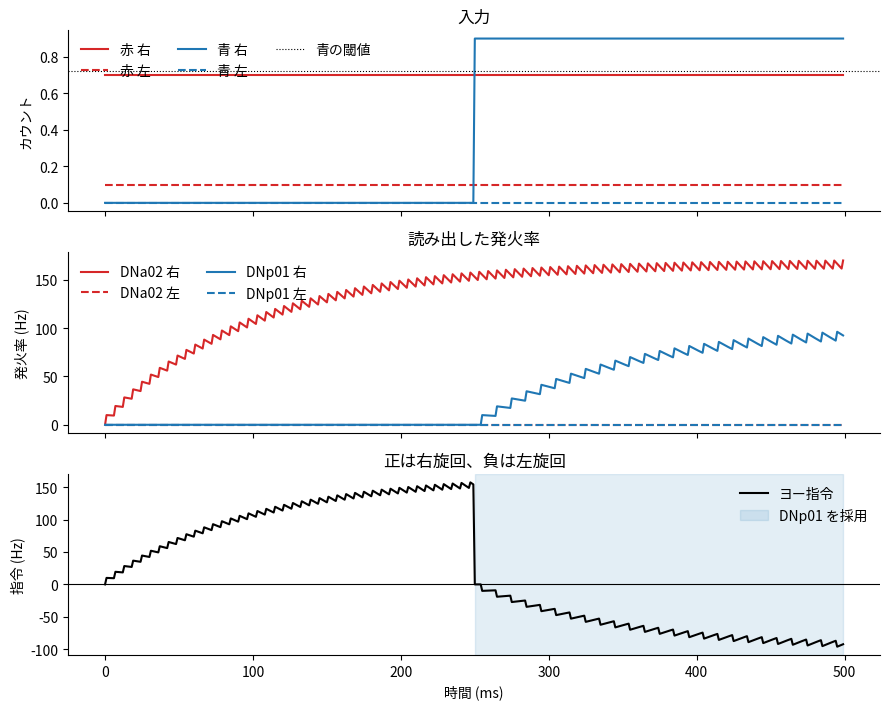

In [5]:
switch = results["switch"]
time_ms = np.arange(len(switch["command"]))
fig, axes = plt.subplots(3, 1, figsize=(9, 7.2), sharex=True)

axes[0].plot(time_ms, switch["red"][:, 1], color="C3", label="赤 右")
axes[0].plot(time_ms, switch["red"][:, 0], color="C3", ls="--", label="赤 左")
axes[0].plot(time_ms, switch["blue"][:, 1], color="C0", label="青 右")
axes[0].plot(time_ms, switch["blue"][:, 0], color="C0", ls="--", label="青 左")
axes[0].axhline(BLUE_OVERRIDE, color="black", lw=0.8, ls=":", label="青の閾値")
axes[0].set_ylabel("カウント")
axes[0].legend(loc="upper left", frameon=False, ncol=3)
axes[0].set_title("入力")

axes[1].plot(time_ms, switch["rates"][:, 3], color="C3", label="DNa02 右")
axes[1].plot(time_ms, switch["rates"][:, 2], color="C3", ls="--", label="DNa02 左")
axes[1].plot(time_ms, switch["rates"][:, 1], color="C0", label="DNp01 右")
axes[1].plot(time_ms, switch["rates"][:, 0], color="C0", ls="--", label="DNp01 左")
axes[1].set_ylabel("発火率 (Hz)")
axes[1].legend(loc="upper left", frameon=False, ncol=2)
axes[1].set_title("読み出した発火率")

axes[2].plot(time_ms, switch["command"], color="black", label="ヨー指令")
axes[2].axhline(0.0, color="black", lw=0.8)
override_on = np.flatnonzero(switch["override"])
if len(override_on):
    axes[2].axvspan(override_on[0], override_on[-1], color="C0", alpha=0.12, label="DNp01 を採用")
axes[2].set_ylabel("指令 (Hz)")
axes[2].set_xlabel("時間 (ms)")
axes[2].legend(loc="upper right", frameon=False)
axes[2].set_title("正は右旋回、負は左旋回")
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.tight_layout()


## 閉ループ

同じ細胞と同じ切替で、平面を走らせる。比較は 3 本。

- 赤と青: 閾値未満は DNa02、超えたフレームは DNp01
- 赤だけ: 障害を見ない。直進して障害に入る
- 青だけ: 目標を見ない。避けたあと、赤へは戻らない

目標に着いたら止まる、という規則は入れていない。巡航速度のまま、目標の近くを通過する。


In [6]:
def simulate(seconds, use_red, use_blue):
    pose = np.array([0.0, 0.0, 0.0])
    cells = [Lif(), Lif(), Lif(), Lif()]
    n = int(round(seconds / DT))
    path = np.zeros((n, 10))
    hold = None
    for t in range(n):
        if t % FRAME == 0:
            red = observe(pose, TARGET, "red") if use_red else (0.0, 0.0)
            blue = observe(pose, OBSTACLE, "blue", OBSTACLE_RADIUS) if use_blue else (0.0, 0.0)
            hold = (red, blue, gf_current(*blue), dna_current(*red))
        red, blue, i_gf, i_dna = hold
        for index, drive in enumerate((i_gf[0], i_gf[1], i_dna[0], i_dna[1])):
            cells[index].step(drive)
        command, override = yaw_command(
            cells[2].rate, cells[3].rate, cells[0].rate, cells[1].rate, blue[0], blue[1]
        )
        steer, omega, v_left, v_right = wheels(command)
        pose[0] += V_CRUISE * np.cos(pose[2]) * DT
        pose[1] += V_CRUISE * np.sin(pose[2]) * DT
        pose[2] = wrap(pose[2] + omega * DT)
        dist_obs = float(np.hypot(pose[0] - OBSTACLE[0], pose[1] - OBSTACLE[1]))
        path[t] = (
            pose[0], pose[1], pose[2], steer, omega, v_left, v_right,
            1.0 if override else 0.0, dist_obs, command,
        )
    return path


courses = {
    "both": simulate(RUN_S, True, True),
    "red": simulate(RUN_S, True, False),
    "blue": simulate(RUN_S, False, True),
}


def closest(path, xy):
    dist = np.hypot(path[:, 0] - xy[0], path[:, 1] - xy[1])
    index = int(np.argmin(dist))
    return float(dist[index]), index * DT


rows = []
for key, label in (("both", "赤と青"), ("red", "赤だけ"), ("blue", "青だけ")):
    path = courses[key]
    obs, t_obs = closest(path, OBSTACLE)
    goal, t_goal = closest(path, TARGET)
    rows.append({
        "条件": label,
        "障害までの最近接 m": obs,
        "障害": "入る" if obs <= OBSTACLE_RADIUS else "よける",
        "目標までの最近接 m": goal,
        "回避した割合": float(path[:, 7].mean()),
        "左輪の最小 m/s": float(path[:, 5].min()),
        "右輪の最小 m/s": float(path[:, 6].min()),
    })
course_table = pd.DataFrame(rows)
print(course_table.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

both_obs, _ = closest(courses["both"], OBSTACLE)
red_obs, _ = closest(courses["red"], OBSTACLE)
both_goal, _ = closest(courses["both"], TARGET)
blue_goal, _ = closest(courses["blue"], TARGET)
if not red_obs < OBSTACLE_RADIUS:
    raise RuntimeError("赤だけでは障害に入る想定が崩れている")
if not both_obs > OBSTACLE_RADIUS:
    raise RuntimeError("赤と青では障害をよける想定が崩れている")
if not both_goal < 0.05:
    raise RuntimeError("赤と青では目標へ寄る想定が崩れている")
if not blue_goal > 0.4:
    raise RuntimeError("青だけでは目標へ寄らない想定が崩れている")
if courses["both"][:, 7].sum() <= 0:
    raise RuntimeError("閉ループで回避へ切り替わっていない")
if courses["both"][:, 5].min() <= 0 or courses["both"][:, 6].min() <= 0:
    raise RuntimeError("車輪が逆回転している。巡航とヨーの定数を見直す")
print()
print(f"障害の半径 {OBSTACLE_RADIUS:.2f} m。赤だけは半径の内側、赤と青は外側を通る。")


 条件  障害までの最近接 m  障害  目標までの最近接 m  回避した割合  左輪の最小 m/s  右輪の最小 m/s
赤と青       0.220 よける       0.000   0.023      0.054      0.131
赤だけ       0.080  入る       0.000   0.000      0.150      0.150
青だけ       0.226 よける       0.579   0.023      0.054      0.150

障害の半径 0.16 m。赤だけは半径の内側、赤と青は外側を通る。


## 経路

上向きが左。青い円が障害、赤い点が目標、黒点がスタート。赤だけは円を横切る。赤と青は円の左を通り、そのあと目標へ戻る。青だけは避けた方位のまま直進する。

下の 2 段は「赤と青」の舵と車輪。回避のあいだは左旋回なので、右輪が速く、左輪が遅い。そのあとの細かい揺れは、片側の DNa02 だけが発火し、スパイクごとに読み出しが 10 Hz 動くためである。


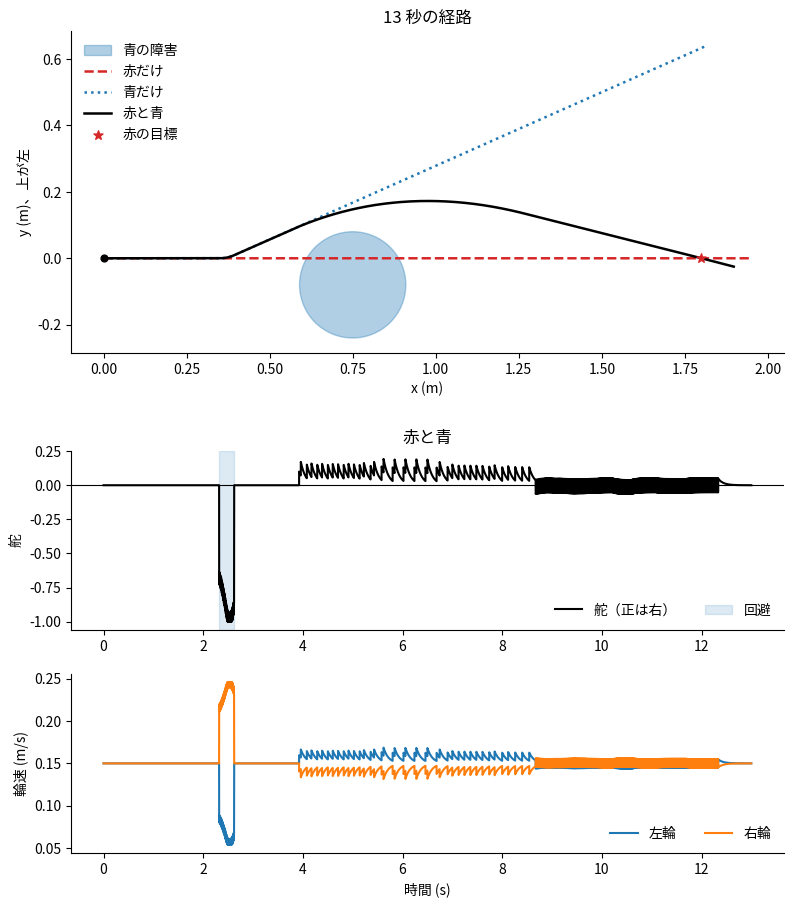

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9.5), gridspec_kw={"height_ratios": [2.4, 1, 1]})
circle = plt.Circle(OBSTACLE, OBSTACLE_RADIUS, facecolor="C0", edgecolor="C0", alpha=0.35, label="青の障害")
axes[0].add_patch(circle)
styles = (
    ("red", "赤だけ", "C3", "--"),
    ("blue", "青だけ", "C0", ":"),
    ("both", "赤と青", "black", "-"),
)
for key, label, color, style in styles:
    path = courses[key]
    axes[0].plot(path[:, 0], path[:, 1], color=color, ls=style, lw=1.8, label=label)
axes[0].scatter([0.0], [0.0], color="black", s=24, zorder=3)
axes[0].scatter([TARGET[0]], [TARGET[1]], color="C3", s=46, marker="*", zorder=3, label="赤の目標")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)、上が左")
axes[0].legend(loc="upper left", frameon=False)
axes[0].set_title("13 秒の経路")

time_s = np.arange(len(courses["both"])) * DT
both = courses["both"]
axes[1].plot(time_s, both[:, 3], color="black", label="舵（正は右）")
axes[1].fill_between(time_s, 0, 1, where=both[:, 7] > 0, color="C0", alpha=0.15, transform=axes[1].get_xaxis_transform(), label="回避")
axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].set_ylabel("舵")
axes[1].legend(loc="lower right", frameon=False, ncol=2)
axes[1].set_title("赤と青")

axes[2].plot(time_s, both[:, 5], label="左輪")
axes[2].plot(time_s, both[:, 6], label="右輪")
axes[2].set_ylabel("輪速 (m/s)")
axes[2].set_xlabel("時間 (s)")
axes[2].legend(loc="lower right", frameon=False, ncol=2)
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.tight_layout()


## 計算量

青のカウントは側の中で一様なので、LC4 と LPLC2 の辺は実行時に足さない。シナプス数の合計は定数で、上の閉形式に入っている。辺ごとに足しても同じ電流になることは、パラメータのセルで確認してある。

車上で細胞ごとに違う発火率を入れるように変えるなら、積和は LC4 と LPLC2 から同側 DNp01 への辺の本数だけになる。DNa02 に足す化学シナプスは 0 本。膜の更新は DNp01 と DNa02 の 4 細胞。


In [8]:
import time

n_feed = int(len(feedforward))
print(f"一様な青カウントでは、実行時の積和は側あたり 1 回（辺 {n_feed} 本分は事前に合計済み）")
print(f"細胞ごとに発火率を変えるなら、1 ms あたりの積和は {n_feed} 回、毎秒 {n_feed * 1000:,} 回")
print("DNa02 の化学シナプスは 0 本。膜の更新は 1 ms あたり 4 細胞。")

sample = results["switch"]
drive = np.array([
    gf_current(0.0, 0.9)[1],
    gf_current(0.0, 0.9)[0],
    dna_current(0.1, 0.7)[0],
    dna_current(0.1, 0.7)[1],
])
repeats = 20
steps = repeats * len(sample["command"])
state = [Lif() for _ in range(4)]
started = time.perf_counter()
for _ in range(repeats):
    for _step in range(len(sample["command"])):
        for index in range(4):
            state[index].step(drive[index])
elapsed = time.perf_counter() - started
print(f"CPython で 4 細胞の 1 ステップ {elapsed / steps * 1e6:.1f} µs（{steps} ステップの平均）")
print("Arduino Uno Q に載せるときの量は、この経過時間ではなく、上の積和回数で見る。")


一様な青カウントでは、実行時の積和は側あたり 1 回（辺 311 本分は事前に合計済み）
細胞ごとに発火率を変えるなら、1 ms あたりの積和は 311 回、毎秒 311,000 回
DNa02 の化学シナプスは 0 本。膜の更新は 1 ms あたり 4 細胞。
CPython で 4 細胞の 1 ステップ 2.3 µs（10000 ステップの平均）
Arduino Uno Q に載せるときの量は、この経過時間ではなく、上の積和回数で見る。


## 読み方

開ループの表で、赤だけの符号は左右のどちらが大きいかに従う。左右が同じだと両方の DNa02 が発火し、差は 0 なので直進になる。赤が右でも電流が 1 を超えない「閾値未満」の行は、スパイクが出ず直進のままである。走性には不感帯がある。`RED_REF` を下げると、弱い赤でも発火する。

青を閾値以上にすると、DNa02 が発火していても指令は DNp01 の差になる。右の青は左旋回、左の青は右旋回。切替そのものはフレームの判定で、発火率のフィルタを混ぜない。DNp01 の発火率が立ち上がる遅れは膜の 5 ms と、読み出しの 100 ms から来る。上に出ているミリ秒は、平滑化した指令が右から左へゼロを横切るまでの時間である。

閉ループでは、障害が進路の右にある。青が閾値を超えるまで直進し、超えると左へ舵を切って円の外を通る。閾値を下回ったあとは DNa02 に戻り、正面から外れた赤い目標の側が発火して目標の近くへ戻る。赤だけはこの回避が無いので円の中を通る。青だけは目標へ戻る電流が無いので、避けた方位のまま進む。

左右の青が同じくらい大きいと、両方の DNp01 が発火して差が消え、回避中のヨーは 0 になる。今回の障害は右へずらしてあり、この正面衝突は経路に出していない。

左右の化学シナプス数は左の方が多い。電流は側ごとにその合計で割っているので、同じ青カウントなら左右の DNp01 は同じ電流になる。割る基準を左の合計に変えると、右は `gf_loom_sim.ipynb` で見たように弱くなる。

変える場所は、パラメータのセルの `RED_REF`、`BLUE_OVERRIDE`、`RATE_SCALE`、`V_CRUISE`、`OMEGA_MAX` と、`TARGET`、`OBSTACLE`。膜の `R_MAX`、`R_REF`、`TAU_MS` は loom のノートと共通。
